In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\bharg\wind_power_forecasting\data\T1.csv')

In [3]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M')
df.set_index('Date/Time', inplace=True)
df.rename(columns={'LV ActivePower (kW)': 'ActivePower', 'Wind Speed (m/s)': 'WindSpeed',
                   'Theoretical_Power_Curve (KWh)': 'TheoreticalPower', 'Wind Direction (°)': 'WindDirection'}, inplace=True)

df['ActivePower'] = df['ActivePower'].clip(lower=0)

In [4]:
# 1. Time Features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

In [5]:
# Cyclical encoding (Very Important for time-series)
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

In [6]:
# 2. Wind Physics Features (This shows domain understanding)
df['WindSpeed_squared'] = df['WindSpeed'] ** 2
df['WindSpeed_cubed']   = df['WindSpeed'] ** 3
df['WindSpeed_4']       = df['WindSpeed'] ** 4

# Wind Direction Components
df['WindDir_rad'] = np.deg2rad(df['WindDirection'])
df['WindDir_sin'] = np.sin(df['WindDir_rad'])
df['WindDir_cos'] = np.cos(df['WindDir_rad'])

In [7]:
# 3. Lag & Rolling Features
for lag in [1, 2, 3, 6, 12]:  # 10min to 2 hours
    df[f'WindSpeed_lag_{lag}'] = df['WindSpeed'].shift(lag)
    df[f'ActivePower_lag_{lag}'] = df['ActivePower'].shift(lag)

# Rolling statistics
for window in [6, 12, 36]:   # 1h, 2h, 6h
    df[f'WindSpeed_roll_mean_{window}'] = df['WindSpeed'].rolling(window).mean()
    df[f'WindSpeed_roll_std_{window}'] = df['WindSpeed'].rolling(window).std()

In [8]:
# 4. Turbine Performance Features
df['PowerCoefficient'] = df['ActivePower'] / (df['TheoreticalPower'] + 1e-6)
df['Efficiency'] = np.where(df['TheoreticalPower'] > 0, 
                           df['ActivePower'] / df['TheoreticalPower'], 0)

# 5. Wind Speed Bins (Operational Regions)
df['WindSpeed_bin'] = pd.cut(df['WindSpeed'], 
                            bins=[0, 3, 12, 25, 50], 
                            labels=['Low', 'Optimal', 'High', 'Extreme'])

print("✅ Feature Engineering Completed!")

✅ Feature Engineering Completed!


In [9]:
df.dropna(inplace=True)

In [10]:
feature_cols = [col for col in df.columns if col not in ['ActivePower', 'TheoreticalPower', 'PowerCoefficient', 'Efficiency', 'WindSpeed_bin']]
X = df[feature_cols]
y = df['ActivePower']

In [11]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (40388, 32) Test shape: (10097, 32)


In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE (kW)": round(mae, 2),
        "RMSE (kW)": round(rmse, 2),
        "R² Score": round(r2, 4)
    })
    
    print(f"\n{name}:")
    print(f"MAE: {mae:.2f} kW | RMSE: {rmse:.2f} kW | R²: {r2:.4f}")


Linear Regression:
MAE: 111.37 kW | RMSE: 160.40 kW | R²: 0.9857

Random Forest:
MAE: 67.66 kW | RMSE: 135.14 kW | R²: 0.9899

XGBoost:
MAE: 71.21 kW | RMSE: 147.46 kW | R²: 0.9879


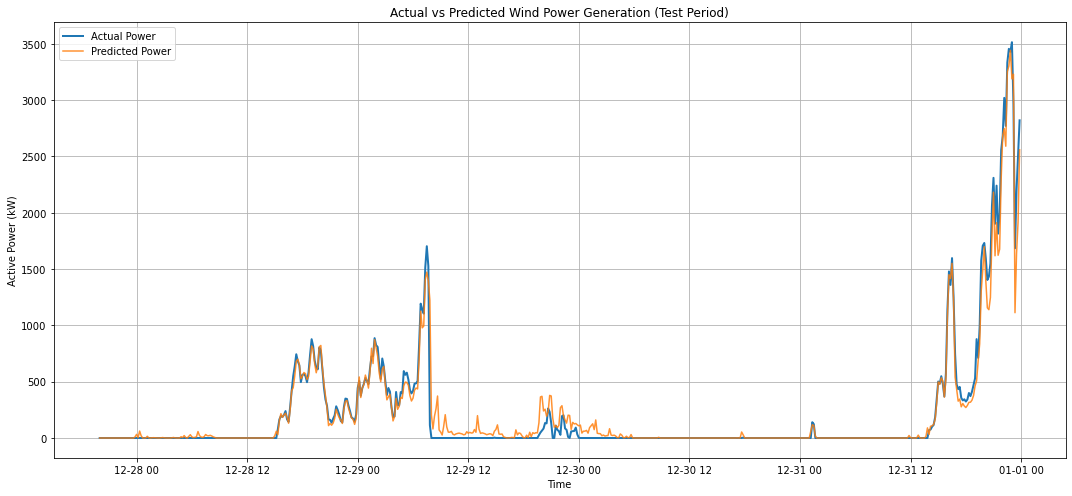

In [15]:
# Best Model Visualization
best_model = models["Random Forest"]   # Change to XGBoost if you prefer
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(15, 7))
plt.plot(y_test.index[-600:], y_test.values[-600:], label='Actual Power', linewidth=2)
plt.plot(y_test.index[-600:], y_pred_best[-600:], label='Predicted Power', alpha=0.85)
plt.title('Actual vs Predicted Wind Power Generation (Test Period)')
plt.xlabel('Time')
plt.ylabel('Active Power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

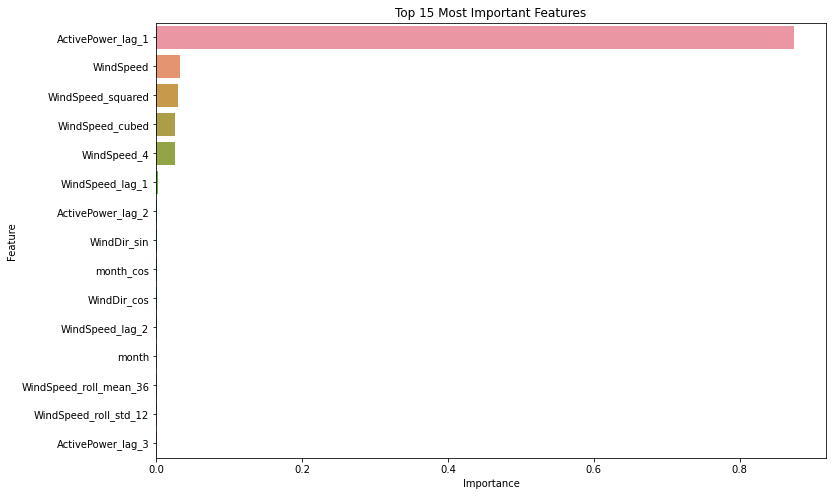


Top 10 Features:
              Feature  Importance
17  ActivePower_lag_1    0.874503
0           WindSpeed    0.032687
10  WindSpeed_squared    0.029523
11    WindSpeed_cubed    0.026450
12        WindSpeed_4    0.025258
16    WindSpeed_lag_1    0.001916
19  ActivePower_lag_2    0.001175
14        WindDir_sin    0.000620
9           month_cos    0.000584
15        WindDir_cos    0.000542


In [18]:
# Feature Importance (Random Forest)
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Most Important Features')
plt.show()

print("\nTop 10 Features:")
print(importance.head(10))

In [20]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE (kW)": [111.37, 67.66, 71.21],
    "RMSE (kW)": [160.40, 135.14, 147.46],
    "R²": [0.9857, 0.9899, 0.9879]
})

print("📊 Final Model Comparison")
display(comparison.style.highlight_max(subset=["R²"], color='lightgreen'))

📊 Final Model Comparison


,Model,MAE (kW),RMSE (kW),R²
0,Linear Regression,111.370000,160.400000,0.985700
1,Random Forest,67.660000,135.140000,0.989900
2,XGBoost,71.210000,147.460000,0.987900


In [23]:
import pickle
import os

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model (Random Forest)
with open('models/random_forest.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Model saved successfully to 'models/random_forest.pkl'")

✅ Model saved successfully to 'models/random_forest.pkl'
